In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Data loading

In [2]:
data_dir = "Sign_language_data" 
classes = sorted(os.listdir(data_dir))

print(classes)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'del', 'space']


### Data processing

In [3]:
img_size = 128

X = []
y = []

for label in classes:
    folder = os.path.join(data_dir, label)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        img = cv2.imread(path)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0

        X.append(img)
        y.append(classes.index(label))

X = np.array(X)
y = np.array(y)

### Data split and setting

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

y_train = to_categorical(y_train, len(classes))
y_test  = to_categorical(y_test, len(classes))

### CNN Model Implementation

In [5]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(len(classes),activation='softmax')
])

In [6]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=35,
    batch_size=32
)

Epoch 1/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 225ms/step - accuracy: 0.1856 - loss: 2.3118 - val_accuracy: 0.3633 - val_loss: 1.8615
Epoch 2/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 212ms/step - accuracy: 0.5044 - loss: 1.4874 - val_accuracy: 0.6767 - val_loss: 0.9656
Epoch 3/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.6842 - loss: 0.9263 - val_accuracy: 0.8017 - val_loss: 0.6430
Epoch 4/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.7656 - loss: 0.6651 - val_accuracy: 0.8217 - val_loss: 0.5609
Epoch 5/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 210ms/step - accuracy: 0.8277 - loss: 0.4888 - val_accuracy: 0.8667 - val_loss: 0.4344
Epoch 6/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 217ms/step - accuracy: 0.8731 - loss: 0.3687 - val_accuracy: 0.8842 - val_loss: 0.3854
Epoch 7/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.8871 - loss: 0.3159 - val_accuracy: 0.8825 - val_loss: 0.3594
Epoch 8/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 214ms/step - accuracy: 0.9181 - loss: 0

In [8]:
loss, acc = cnn_model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9025 - loss: 0.4700
Test Accuracy: 0.9024999737739563


In [9]:
cnn_model.save("sign_language_model_cnn.h5")

### RNN Model implementation

In [10]:
X_train_rnn = X_train.reshape(X_train.shape[0], 128, 128*3)
X_test_rnn  = X_test.reshape(X_test.shape[0], 128, 128*3)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

rnn_model = Sequential([
    LSTM(128, input_shape=(128,384), return_sequences=False),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dense(len(classes), activation="softmax")
])

In [12]:
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history_rnn = rnn_model.fit(
    X_train_rnn, y_train,
    validation_data=(X_test_rnn, y_test),
    epochs=35,
    batch_size=32
)

Epoch 1/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - accuracy: 0.0931 - loss: 2.5034 - val_accuracy: 0.1133 - val_loss: 2.4624
Epoch 2/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.1110 - loss: 2.4692 - val_accuracy: 0.1117 - val_loss: 2.4371
Epoch 3/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - accuracy: 0.1302 - loss: 2.4290 - val_accuracy: 0.1458 - val_loss: 2.3881
Epoch 4/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.1379 - loss: 2.3874 - val_accuracy: 0.1633 - val_loss: 2.3449
Epoch 5/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.1729 - loss: 2.3089 - val_accuracy: 0.1833 - val_loss: 2.2440
Epoch 6/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.1823 - loss: 2.2341 - val_accuracy: 0.2108 - val_loss: 2.1467
Epoch 7/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.1904 - loss: 2.1848 - val_accuracy: 0.2192 - val_loss: 2.0923
Epoch 8/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.2035 - loss: 2

In [14]:
loss, acc = rnn_model.evaluate(X_test_rnn,y_test)
print("RNN Accuracy:",acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5017 - loss: 1.4090
RNN Accuracy: 0.5016666650772095


In [15]:
rnn_model.save("sign_language_model_rnn.h5")

### Transfer Learning implementation

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dense(128, activation="relu")(x)
output = Dense(len(classes), activation="softmax")(x)

transfer_model = Model(inputs=base.input, outputs=output)

In [17]:
transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_test,y_test),
    epochs=35,
    batch_size=32
)

Epoch 1/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - accuracy: 0.8467 - loss: 0.5025 - val_accuracy: 0.9542 - val_loss: 0.1749
Epoch 2/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.9712 - loss: 0.1106 - val_accuracy: 0.9642 - val_loss: 0.1108
Epoch 3/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 187ms/step - accuracy: 0.9860 - loss: 0.0548 - val_accuracy: 0.9733 - val_loss: 0.0903
Epoch 4/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - accuracy: 0.9935 - loss: 0.0288 - val_accuracy: 0.9692 - val_loss: 0.0874
Epoch 5/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.9965 - loss: 0.0186 - val_accuracy: 0.9825 - val_loss: 0.0615
Epoch 6/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.9996 - loss: 0.0104 - val_accuracy: 0.9833 - val_loss: 0.0431
Epoch 7/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9867 - val_loss: 0.0405
Epoch 8/35
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 1.0000 - loss: 0

In [19]:
loss, acc = transfer_model.evaluate(X_test,y_test)
print("Transfer Model Accuracy:",acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9875 - loss: 0.0299    
Transfer Model Accuracy: 0.987500011920929


In [20]:
transfer_model.save("sign_language_model_tr.h5")

### Testing using Transfer Model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
Predicted: 0


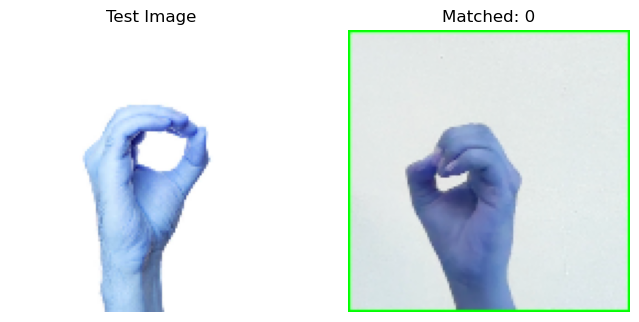

In [21]:
img_path = "test_data/test_image1.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = transfer_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted: 4


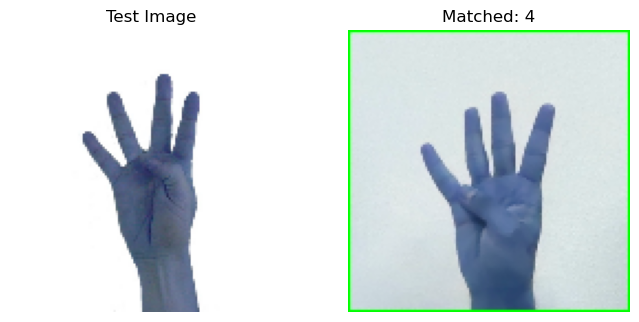

In [22]:
img_path = "test_data/test_image2.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = transfer_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted: 6


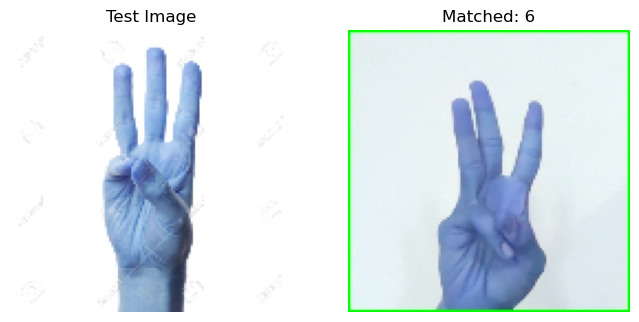

In [23]:
img_path = "test_data/test_image3.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = transfer_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted: 1


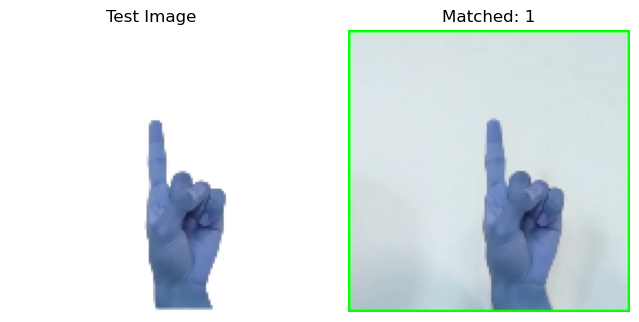

In [24]:
img_path = "test_data/test_image4.png"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = transfer_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted: space


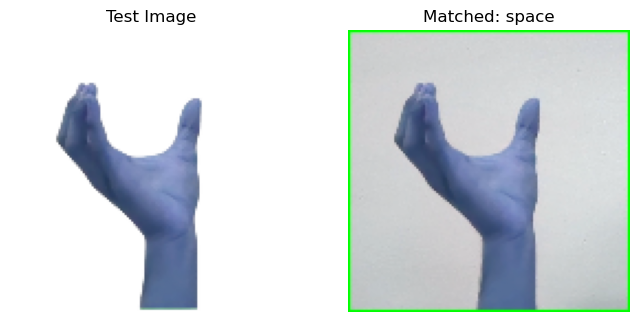

In [25]:
img_path = "test_data/test_image5.png"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = transfer_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

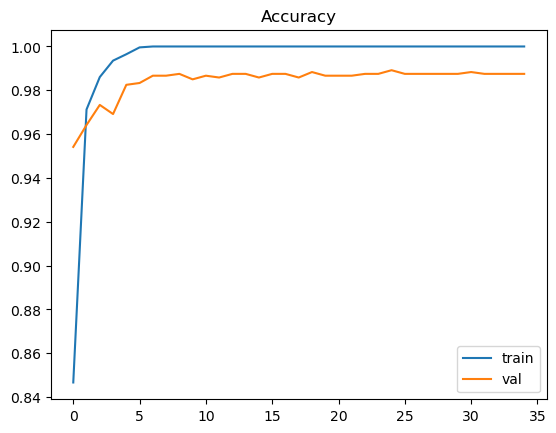

In [26]:
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

### Testing using CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Predicted: del


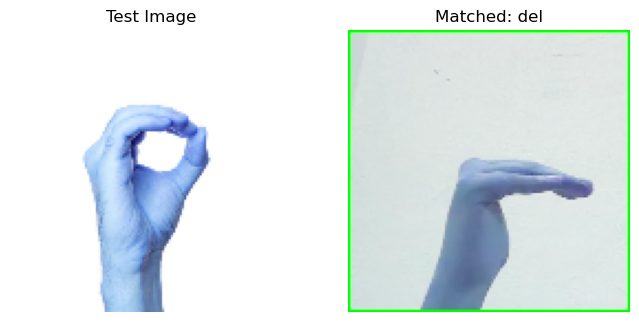

In [27]:
img_path = "test_data/test_image1.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = cnn_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted: 4


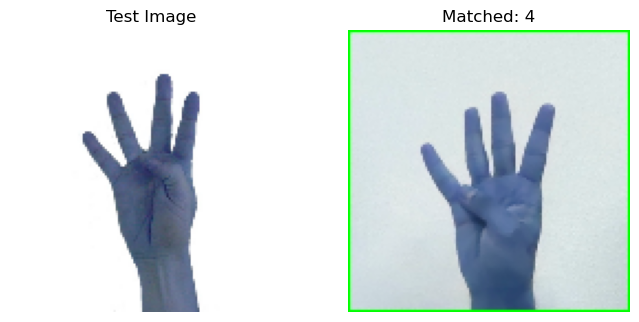

In [28]:
img_path = "test_data/test_image2.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = cnn_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: 2


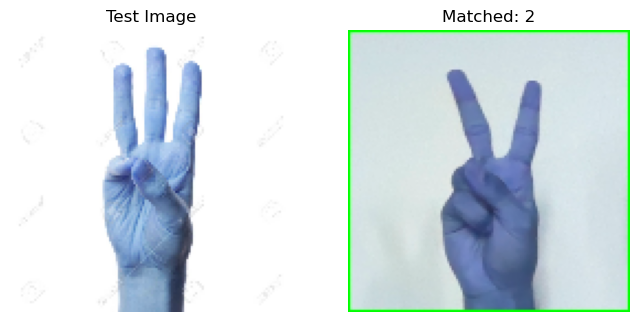

In [29]:
img_path = "test_data/test_image3.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = cnn_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted: 1


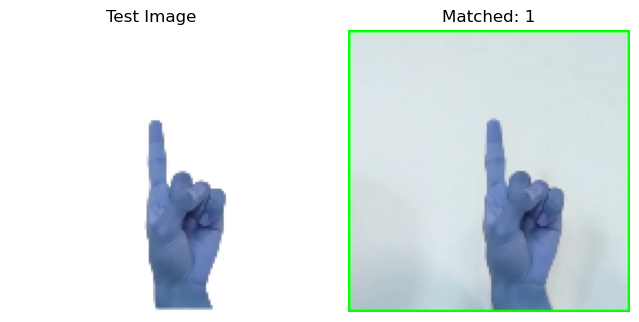

In [30]:
img_path = "test_data/test_image4.png"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = cnn_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted: space


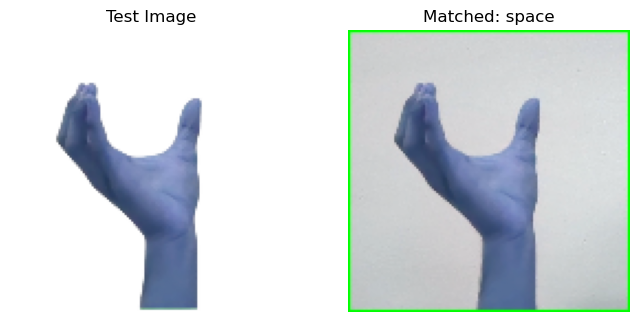

In [31]:
img_path = "test_data/test_image5.png"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0
img = np.expand_dims(img,axis=0)

prediction = cnn_model.predict(img)
class_index = np.argmax(prediction)

print("Predicted:", classes[class_index])


# -------- MATCHING IMAGE --------

predicted_label = classes[class_index]
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    score = np.mean((img[0] - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# show result
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

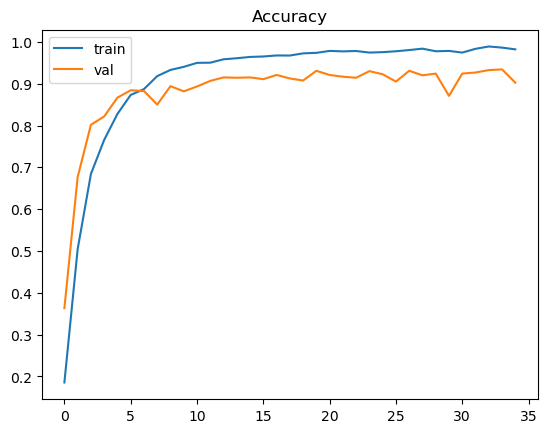

In [32]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

### Testing using RNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Predicted: 0


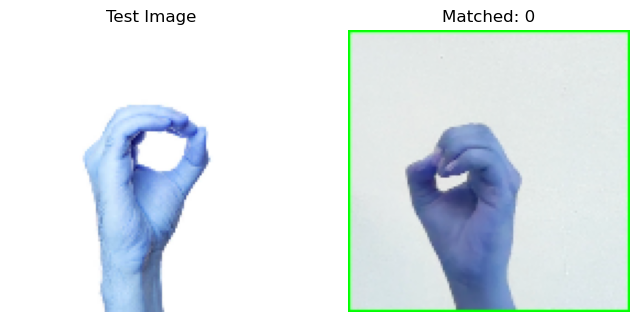

In [33]:
img_path = "test_data/test_image1.jpg"

# -------- LOAD IMAGE --------
img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

original_img = img.copy()   # keep original for display + matching

# normalize for model
img = img/255.0

# reshape for RNN model
img_rnn = img.reshape(1,128,384)


# -------- PREDICTION --------
prediction = rnn_model.predict(img_rnn)
class_index = np.argmax(prediction)

predicted_label = classes[class_index]
print("Predicted:", predicted_label)


# -------- MATCHING IMAGE --------
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    # compare using original image
    score = np.mean((original_img/255.0 - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# -------- DISPLAY --------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted: 1


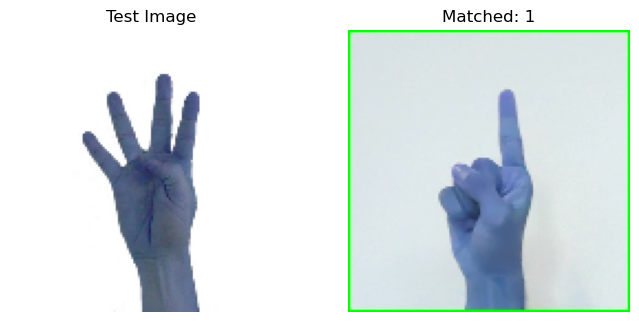

In [34]:
img_path = "test_data/test_image2.jpg"

# -------- LOAD IMAGE --------
img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

original_img = img.copy()   # keep original for display + matching

# normalize for model
img = img/255.0

# reshape for RNN model
img_rnn = img.reshape(1,128,384)


# -------- PREDICTION --------
prediction = rnn_model.predict(img_rnn)
class_index = np.argmax(prediction)

predicted_label = classes[class_index]
print("Predicted:", predicted_label)


# -------- MATCHING IMAGE --------
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    # compare using original image
    score = np.mean((original_img/255.0 - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# -------- DISPLAY --------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted: 0


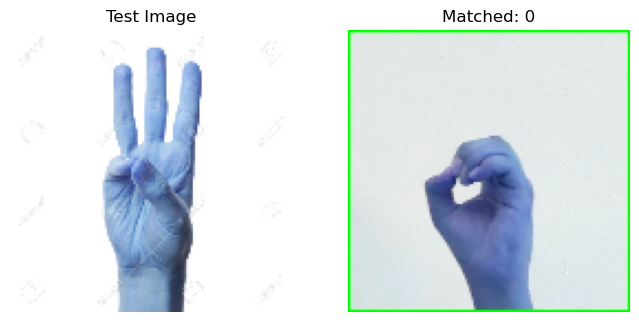

In [35]:
img_path = "test_data/test_image3.jpg"

# -------- LOAD IMAGE --------
img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

original_img = img.copy()   # keep original for display + matching

# normalize for model
img = img/255.0

# reshape for RNN model
img_rnn = img.reshape(1,128,384)


# -------- PREDICTION --------
prediction = rnn_model.predict(img_rnn)
class_index = np.argmax(prediction)

predicted_label = classes[class_index]
print("Predicted:", predicted_label)


# -------- MATCHING IMAGE --------
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    # compare using original image
    score = np.mean((original_img/255.0 - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# -------- DISPLAY --------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted: 0


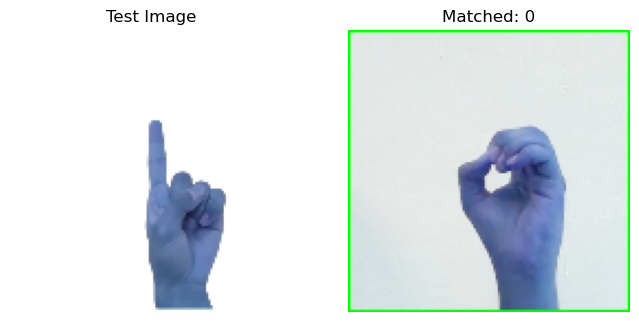

In [36]:
img_path = "test_data/test_image4.png"

# -------- LOAD IMAGE --------
img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

original_img = img.copy()   # keep original for display + matching

# normalize for model
img = img/255.0

# reshape for RNN model
img_rnn = img.reshape(1,128,384)


# -------- PREDICTION --------
prediction = rnn_model.predict(img_rnn)
class_index = np.argmax(prediction)

predicted_label = classes[class_index]
print("Predicted:", predicted_label)


# -------- MATCHING IMAGE --------
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    # compare using original image
    score = np.mean((original_img/255.0 - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# -------- DISPLAY --------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted: 0


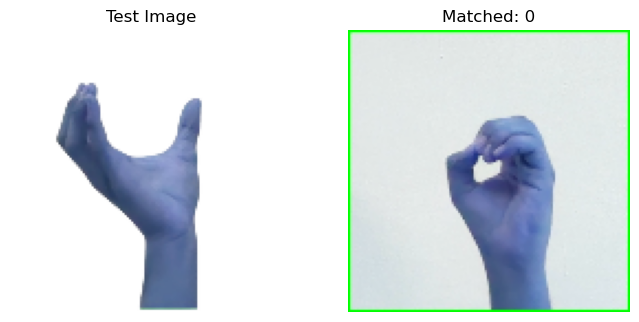

In [37]:
img_path = "test_data/test_image5.png"

# -------- LOAD IMAGE --------
img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))

original_img = img.copy()   # keep original for display + matching

# normalize for model
img = img/255.0

# reshape for RNN model
img_rnn = img.reshape(1,128,384)


# -------- PREDICTION --------
prediction = rnn_model.predict(img_rnn)
class_index = np.argmax(prediction)

predicted_label = classes[class_index]
print("Predicted:", predicted_label)


# -------- MATCHING IMAGE --------
folder_path = os.path.join(data_dir, predicted_label)

best_score = float("inf")
best_img = None

for file in os.listdir(folder_path):

    path = os.path.join(folder_path, file)

    dataset_img = cv2.imread(path)
    dataset_img = cv2.resize(dataset_img,(128,128))
    dataset_img = dataset_img/255.0

    # compare using original image
    score = np.mean((original_img/255.0 - dataset_img)**2)

    if score < best_score:
        best_score = score
        best_img = dataset_img


# -------- DISPLAY --------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(best_img)
plt.title(f"Matched: {predicted_label}")
plt.axis("off")

plt.show()

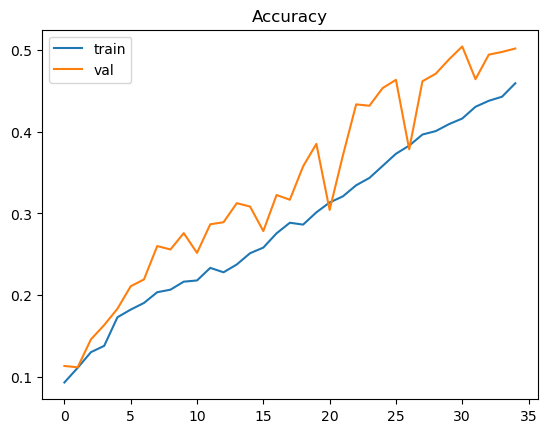

In [38]:
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()